Loan Approval Prediction using Decision Tree Algorithm

1. Pre-process the data (to fit in decision tree)

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

data = pd.read_csv("loan_approval_dataset.csv")

# Drop ID column
data = data.drop(columns=["loan_id"])

# Encode target
data["loan_status"] = data["loan_status"].map({"Approved": 1, "Rejected": 0})

# Encode categorical columns
le = LabelEncoder()
for col in ["gender", "education", "employment_status", "property_area"]:
    data[col] = le.fit_transform(data[col])

# Impute missing values with median
imputer = SimpleImputer(strategy="median")
data[data.columns] = imputer.fit_transform(data)

print("Encoded Dataset Sample:")
print(data.head())

data.to_csv("loan_data_preprocessed.csv", index=False)
print("Saved as loan_data_preprocessed.csv")

Encoded Dataset Sample:
    age  gender  education  employment_status  employment_years  dependents  \
0  59.0     1.0        0.0                1.0               7.0         1.0   
1  49.0     1.0        0.0                1.0               8.0         4.0   
2  35.0     0.0        1.0                2.0               2.0         1.0   
3  63.0     1.0        0.0                2.0               1.0         0.0   
4  28.0     1.0        1.0                1.0              12.0         1.0   

   applicant_income  coapplicant_income  total_income  loan_amount  \
0           21442.0                 0.0       21442.0      66595.0   
1           50112.0                 0.0       50112.0     229675.0   
2           65981.0                 0.0       65981.0     324608.0   
3           56997.0                 0.0       56997.0     270501.0   
4           14983.0             16792.0       31775.0     103340.0   

   loan_term_months  credit_score  existing_emis  monthly_obligations  \
0      

2. Import the necessary libraries

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

3. Load the preprocessed dataset

In [3]:
df = pd.read_csv("loan_data_preprocessed.csv")
df.head()

,age,gender,education,employment_status,employment_years,dependents,applicant_income,coapplicant_income,total_income,loan_amount,loan_term_months,credit_score,existing_emis,monthly_obligations,dti_ratio,collateral_value,loan_to_value,property_area,loan_status
0,59.0,1.0,0.0,1.0,7.0,1.0,21442.0,0.0,21442.0,66595.0,84.0,598.0,0.0,0.0,0.4432,36281.0,1.8355,1.0,0.0
1,49.0,1.0,0.0,1.0,8.0,4.0,50112.0,0.0,50112.0,229675.0,12.0,626.0,3.0,15545.0,8.3056,180178.0,1.2747,1.0,0.0
2,35.0,0.0,1.0,2.0,2.0,1.0,65981.0,0.0,65981.0,324608.0,180.0,665.0,0.0,0.0,0.3279,334218.0,0.9712,1.0,1.0
3,63.0,1.0,0.0,2.0,1.0,0.0,56997.0,0.0,56997.0,270501.0,120.0,752.0,1.0,8810.0,2.3294,475045.0,0.5694,2.0,1.0
4,28.0,1.0,1.0,1.0,12.0,1.0,14983.0,16792.0,31775.0,103340.0,60.0,626.0,2.0,20389.0,8.3503,249374.0,0.4144,0.0,0.0


4. Extract features and label; split the dataset into train and test datasets

In [4]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45, stratify=y)

In [5]:
X.columns.tolist()

['age',
 'gender',
 'education',
 'employment_status',
 'employment_years',
 'dependents',
 'applicant_income',
 'coapplicant_income',
 'total_income',
 'loan_amount',
 'loan_term_months',
 'credit_score',
 'existing_emis',
 'monthly_obligations',
 'dti_ratio',
 'collateral_value',
 'loan_to_value',
 'property_area']

5. Train the Decision Tree Classifier Model with training data

In [6]:
dt_model = DecisionTreeClassifier(random_state=45)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=45)

6. Check the model performance - accuracy, precision, recall, F1 score

In [7]:
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["Rejected", "Approved"])

print(f"Model Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(report)

Model Accuracy: 0.89
Confusion Matrix:
[[1237  115]
 [ 115  533]]
Classification Report:
              precision    recall  f1-score   support

    Rejected       0.91      0.91      0.91      1352
    Approved       0.82      0.82      0.82       648

    accuracy                           0.89      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.89      0.89      0.89      2000



7. Visualize the decision tree

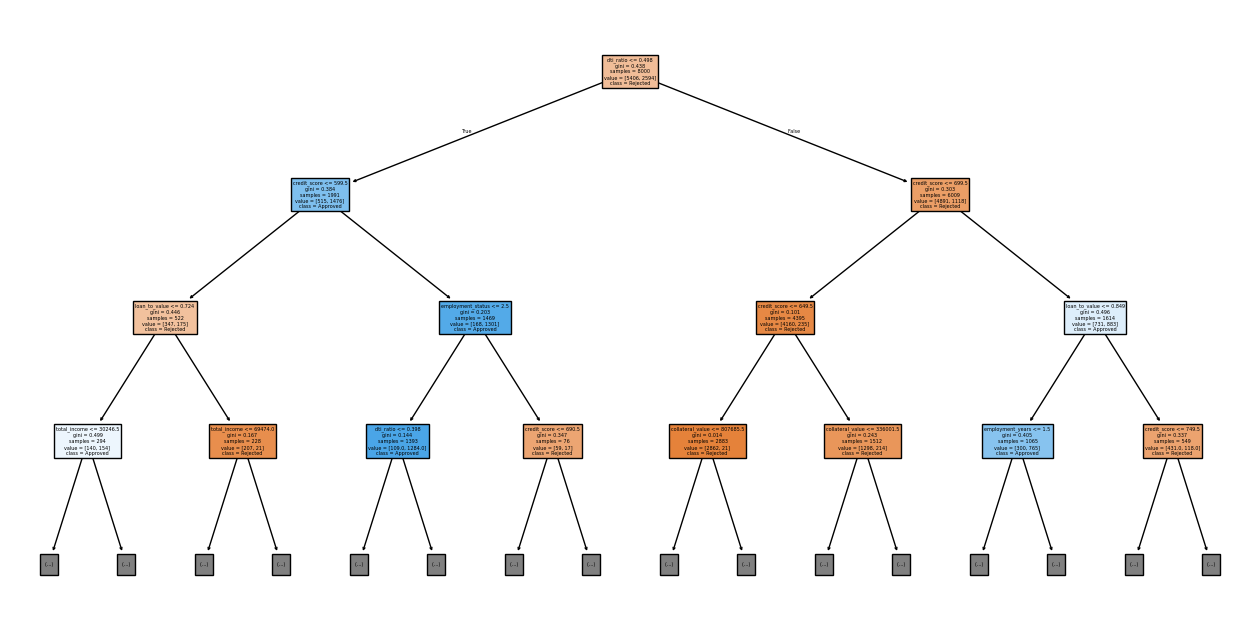

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=["Rejected", "Approved"], max_depth=3)
plt.show()

8. Control overfitting by limiting the tree's complexity

In [9]:
dt_tuned = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=75,
    min_samples_leaf=40,
    random_state=45
)

dt_tuned.fit(X_train, y_train)
y_pred_tuned = dt_tuned.predict(X_test)

print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%")
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=["Rejected", "Approved"]))
print("Tuned Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Model Accuracy: 90.05%
Tuned Model Classification Report:
              precision    recall  f1-score   support

    Rejected       0.92      0.93      0.93      1352
    Approved       0.85      0.84      0.84       648

    accuracy                           0.90      2000
   macro avg       0.89      0.88      0.89      2000
weighted avg       0.90      0.90      0.90      2000

Tuned Model Confusion Matrix:
[[1259   93]
 [ 106  542]]


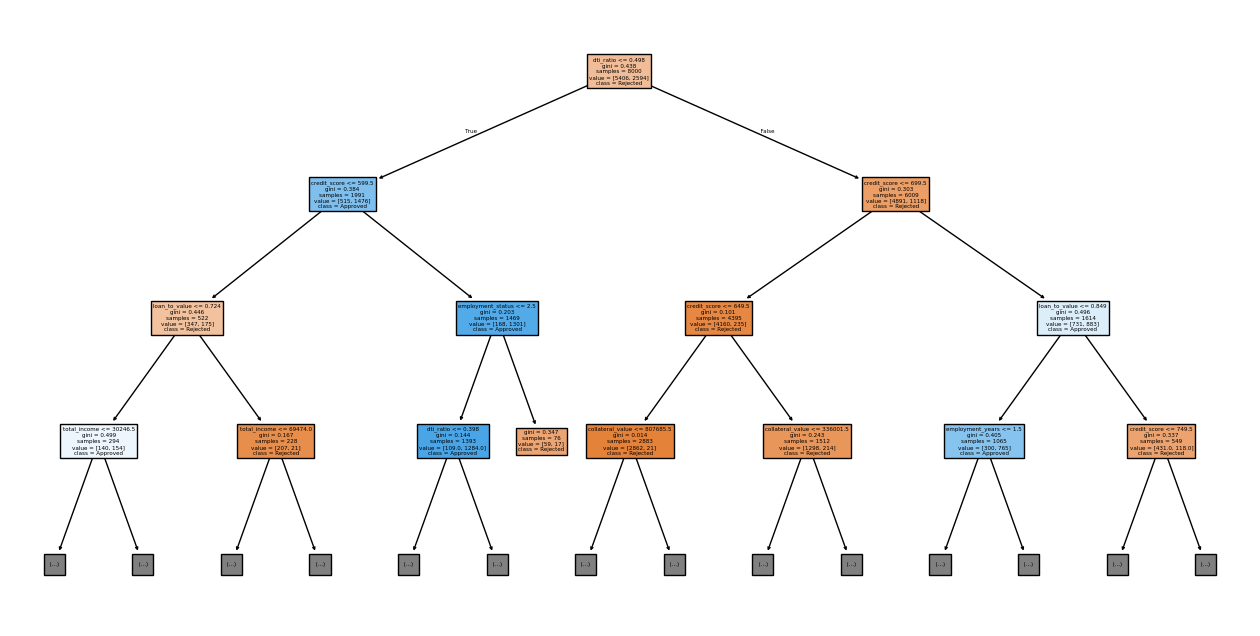

In [10]:
plt.figure(figsize=(16, 8))
plot_tree(dt_tuned, filled=True, feature_names=X.columns, class_names=["Rejected", "Approved"], max_depth=3)
plt.show()

9. Test it with a mock input

In [11]:
mock_input = pd.DataFrame([{
    "age": 32,
    "gender": 1,
    "education": 0,
    "employment_status": 1,
    "employment_years": 6,
    "dependents": 2,
    "applicant_income": 45000,
    "coapplicant_income": 15000,
    "total_income": 60000,
    "loan_amount": 200000,
    "loan_term_months": 360,
    "credit_score": 700,
    "existing_emis": 1,
    "monthly_obligations": 5000,
    "dti_ratio": 0.35,
    "collateral_value": 250000,
    "loan_to_value": 0.80,
    "property_area": 2
}])

prediction = dt_tuned.predict(mock_input)
print("Predicted Loan Status:", "Approved" if prediction[0] == 1 else "Rejected")

Predicted Loan Status: Approved
